<a href="https://colab.research.google.com/github/Redcoder815/Machine_learning_phitron/blob/main/48ml_assignment_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML Assignment 02
### Dataset: House Price Prediction Dataset
### Total Marks: 100

---

## Exam Instructions:
1. প্রথমে নিচের cell এ নিজের **নাম** এবং কোর্সে registration করা **ইমেইল** দিবে
2. Question wise numbering করে Text cell রাখবে এবং এর নিচে Code cell থাকবে, চেষ্টা করবে একটি code cell এ একটি question উত্তর দেওয়ার
3. Google Colab এর মধ্যে কোডগুলো করবে
4. এবং সেই ফাইলটি **'Anyone with the link' & 'View' Access** দিয়ে ফাইলটির Shareable Link টি সাবমিট করবে

---

**Question Dataset Link:** https://www.kaggle.com/datasets/prokshitha/home-value-insights

## Student Information

---
## Question 1 (10 Marks)

Load the House Price dataset and display:
- Dataset shape
- First 10 rows
- 5 random samples

In [ ]:
# Question 1
import pandas as pd
df = pd.read_csv('/content/house_price_regression_dataset.csv')
print(df.shape)
print(df.head(10))
print(df.sample(5))

(1000, 8)
   Square_Footage  Num_Bedrooms  Num_Bathrooms  Year_Built  Lot_Size  \
0            1360             2              1        1981  0.599637   
1            4272             3              3        2016  4.753014   
2            3592             1              2        2016  3.634823   
3             966             1              2        1977  2.730667   
4            4926             2              1        1993  4.699073   
5            3944             5              3        1990  2.475930   
6            3671             1              2        2012  4.911960   
7            3419             1              1        1972  2.805281   
8             630             3              3        1997  1.014286   
9            2185             4              2        1981  3.941604   

   Garage_Size  Neighborhood_Quality   House_Price  
0            0                     5  2.623829e+05  
1            1                     6  9.852609e+05  
2            0                     9  

---
## Question 2 (10 Marks)

Handle missing values and perform feature engineering:
- Impute missing numerical values using `SimpleImputer` with mean strategy
- Impute missing categorical values using most frequent strategy
- Drop columns with more than 50% missing values
- Perform train-test split with `test_size=0.2` and `random_state=42`

Display the shape of final train and test sets.

In [ ]:
df

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06
...,...,...,...,...,...,...,...,...
995,3261,4,1,1978,2.165110,2,10,7.014940e+05
996,3179,1,2,1999,2.977123,1,10,6.837232e+05
997,2606,4,2,1962,4.055067,0,2,5.720240e+05
998,4723,5,2,1950,1.930921,0,7,9.648653e+05


In [ ]:
#Question 2
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
import numpy as np

In [ ]:
# print(df.isnull().sum())

df = df.loc[:, lambda x: x.isnull().mean() <= 0.5]

X = df.drop(columns=['House_Price'], axis = 1)
y = df['House_Price']

X_train, X_test , y_train, y_test = train_test_split(X,y,test_size = 0.2, random_state = 42)

num_feature = X_train.select_dtypes(
    include = ["int64","float64"]
).columns

# print(num_feature)

cat_features = X_train.select_dtypes(
    include= ["object"]
).columns

# print(cat_features)

if len(num_feature) > 0:
  num_imputor = SimpleImputer(missing_values=np.nan, strategy='mean')
  num_imputor.fit(X_train[num_feature])
  X_train[num_feature] = num_imputor.transform(X_train[num_feature])
  X_test[num_feature] = num_imputor.transform(X_test[num_feature])

if len(cat_features) > 0:
    cat_imputor = SimpleImputer(missing_values=np.nan, strategy='most_frequent')
    cat_imputor.fit(X_train[cat_features])
    X_train[cat_features] = cat_imputor.transform(X_train[cat_features])
    X_test[cat_features] = cat_imputor.transform(X_test[cat_features])

# print(df.isnull().sum())

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(800, 7)
(200, 7)
(800,)
(200,)


---
## Question 3 (20 Marks)

Implement **Simple Linear Regression** using **only NumPy** (no Scikit-Learn allowed):
- Compute slope (`m`) and intercept (`c`) using the Batch Gradient Descent
- Predict values for the test set
- Print the learned `m` and `c` values

Use `Square_Footage` as feature (X) and `House_Price` as target (y).

In [ ]:
#Question 3
def make_prediction(X, m, c):
  n = X.shape[0]
  pred_list = np.zeros((n,))

  for i in range(n):
    pred_list[i] = m * X[i] + c

  return pred_list

def calculate_gradient(X, y, m, c):
  n = X.shape[0]
  dj_dw = 0.0
  dj_db = 0.0

  for i in range(n):
    prediction = m * X[i] + c
    error = prediction - y[i]
    dj_dw = dj_dw + (error * X[i])
    dj_db = dj_db + error

  return dj_dw / n, dj_db / n

def gradient_descent(X, y, w_input, b_input, max_iter, alpha=0.01):
  m = w_input
  c = b_input

  for i in range(max_iter):
    dj_dw, dj_db = calculate_gradient(X, y, m, c)

    m = m - alpha * dj_dw
    c = c - alpha * dj_db

    # cost = compute_cost(X, y, m, c)

  return m, c

In [ ]:
df_copy = df.copy()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

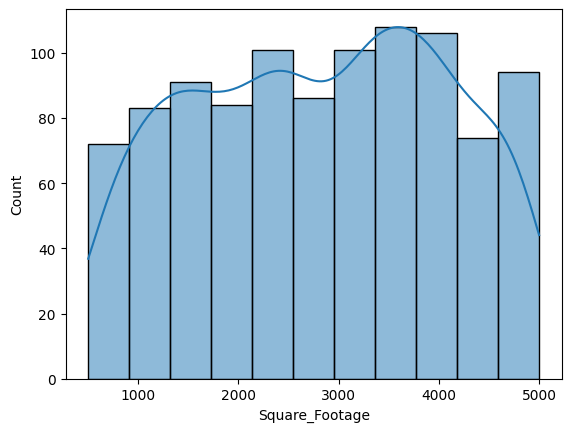

In [ ]:
sns.histplot(data = df_copy, x = 'Square_Footage', kde = True)
plt.show()

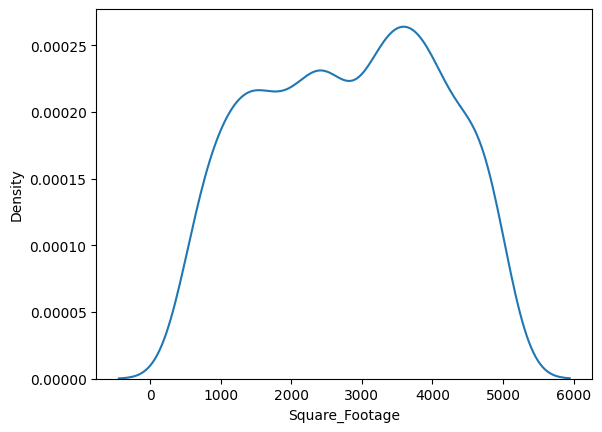

In [ ]:
sns.kdeplot(data = df_copy, x = 'Square_Footage')
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler,OneHotEncoder

In [ ]:
X_Lr = df_copy[['Square_Footage']]
y_Lr = df_copy[['House_Price']]

In [ ]:
X_Lr

,Square_Footage
0,1360
1,4272
2,3592
3,966
4,4926
...,...
995,3261
996,3179
997,2606
998,4723


In [ ]:
y_Lr

,House_Price
0,2.623829e+05
1,9.852609e+05
2,7.779774e+05
3,2.296989e+05
4,1.041741e+06
...,...
995,7.014940e+05
996,6.837232e+05
997,5.720240e+05
998,9.648653e+05


In [ ]:
X_train, X_test , y_train, y_test = train_test_split(X_Lr,y_Lr,test_size = 0.2, random_state = 42)

In [ ]:
ss = StandardScaler()

ss.fit(X_train[['Square_Footage']])

X_train['Square_Footage'] = ss.transform(X_train[['Square_Footage']]).ravel()
X_test['Square_Footage'] = ss.transform(X_test[['Square_Footage']]).ravel()

In [ ]:
X_train = X_train['Square_Footage'].values
y_train = y_train['House_Price'].values
m,c = gradient_descent(X_train, y_train, w_input=0, b_input=0, max_iter=10000, alpha=0.01)
print(m,c)

251094.52785926187 618576.0544203798


In [ ]:
predicted_values = make_prediction(X_test['Square_Footage'].values, m, c)

print(predicted_values)

[ 858863.24859833  517515.44416558  998450.83489986 1043375.57531874
  785459.43166391  773426.01905171  984411.85351895  881927.28943838
  812534.61004136  905191.8871553   778239.38409659  669537.55683305
  210663.42255448 1041971.67718065  568657.44776744  231721.89462583
  492646.3914337   396178.53365923  722484.57232673  330195.321169
  747353.62505861  514306.53413566  719275.66229681  883932.85820708
  444312.18410803  345838.75756486  452133.90230596  437092.13654071
  238139.71468567  451532.23167535  270830.48561548  909203.0246927
  762395.39082386  333805.34495266  481615.76320585  777838.27034285
  476000.17065349  571866.35779736  249571.45666726  186797.15420695
  320969.70483298  255187.04921962  498462.54086293  309738.51972826
 1056010.65856155  929258.7123797   798696.18553733  811932.93941075
  991030.23045567  734317.42806206  256791.50423458  728300.72175596
  790272.79670879  700824.42962477  516713.2166581   796690.61676863
  181983.78916207  308735.73534391  7

---
## Question 4 (10 Marks)

Build a **ColumnTransformer** that applies:
- `StandardScaler` on numerical columns: `Square_Footage`, `Num_Bedrooms`, `Num_Bathrooms`
- `OneHotEncoder` on categorical column: `Neighborhood_Quality`



In [ ]:
#Question 4
num_feature = ['Square_Footage', 'Num_Bedrooms', 'Num_Bathrooms']
cat_features = ['Neighborhood_Quality']

num_transformer = Pipeline(
    steps = [
        ("scaler", StandardScaler())
    ]
)

cat_transformer = Pipeline(
    steps = [
        ("encoder",OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers = [
        ("num",num_transformer,num_feature),
        ("cat",cat_transformer,cat_features)
    ]
)

## Question 5 (20 Marks)

Build a complete **Pipeline** using Scikit-Learn that includes:
- The `ColumnTransformer`
- `SGDRegressor` as the final estimator
- Train the pipeline and evaluate using RMSE and R² score
- Print predicted vs actual values for the first 10 test samples

In [ ]:
from sklearn.linear_model import LinearRegression,SGDRegressor
from sklearn.metrics import r2_score,mean_squared_error

In [ ]:
# Question 5
X_train, X_test , y_train, y_test = train_test_split(X,y,test_size = 0.2, random_state = 42)

sgd_pipeline = Pipeline(
    steps = [
        ("preprocessor",preprocessor),
        ("model", SGDRegressor(random_state = 42))
    ]
)

sgd_pipeline.fit(X_train, y_train)

y_pred = sgd_pipeline.predict(X_test)

print(f"r2 score: {r2_score(y_test, y_pred)}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred))}")

print(f"Actual values: {y_test.iloc[:10].values} and predicted value: {y_pred[:10]}")

r2 score: 0.9868659781432683
RMSE: 29096.460915896132
Actual values: [ 901000.48823382  494537.5115455   949404.20066573 1040389.04813578
  794010.01673364  724033.56045713  998439.23711398  909713.4350007
  792681.51842008  947490.77747782] and predicted value: [ 851369.90594294  507342.81808969  985831.68390361 1022464.73717754
  759809.07504561  765675.68037077 1004527.78475431  903546.04648129
  797193.07767156  888626.74422641]


---
## Question 6 (20 Marks)

Implement **Multiple Linear Regression** using **Scikit-Learn**:
- The `ColumnTransformer`
- `LinearRegression` as the final estimator
- Train the pipeline and evaluate using RMSE and R² score
- Print predicted vs actual values for the first 10 test samples

In [ ]:
# Question 5

lr_pipeline = Pipeline(
    steps = [
        ("preprocessor",preprocessor),
        ("model", LinearRegression())
    ]
)

lr_pipeline.fit(X_train, y_train)

y_pred = lr_pipeline.predict(X_test)

print(f"r2 score: {r2_score(y_test, y_pred)}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred))}")

print(f"Actual values: {y_test.iloc[:10].values} and predicted value: {y_pred[:10]}")

r2 score: 0.986869034559103
RMSE: 29093.07520285173
Actual values: [ 901000.48823382  494537.5115455   949404.20066573 1040389.04813578
  794010.01673364  724033.56045713  998439.23711398  909713.4350007
  792681.51842008  947490.77747782] and predicted value: [ 851409.14732655  507641.0338697   985990.37503164 1022654.70653384
  760698.13365681  765782.31638091 1005039.09634383  903407.78177236
  797971.18840959  888850.4300377 ]


---
## Question 6 (10 Marks) (You have to explore the topic and use the equation via Numpy)
### Dont use LLMs , You can use Documentation

Implement **Multiple Linear Regression** using **only NumPy**:
- Pick random 100 datas from the dataset
- Use the Normal Equation: `θ = (XᵀX)⁻¹ Xᵀy`
- Use `Square_Footage`, `Num_Bedrooms`, and `Num_Bathrooms` as features
- Print the learned coefficients (θ values)

In [ ]:
# Question 7
def make_prediction(X, W, b):
  m = X.shape[0]
  pred_list = np.zeros((m,))

  for i in range(m):
    pred_list[i] = np.dot(W,X[i]) + b

  return pred_list


def compute_cost(X, y, W, b):
  m = X.shape[0]
  cost = 0.0

  pred_list = make_prediction(X,W,b)

  error = pred_list - y

  error_squared = error ** 2

  cost = np.sum(error_squared)

  cost = cost / (2 * m)

  return cost

def calculate_gradient(X, y, W, b):
  m = X.shape[0]
  n = X.shape[1]

  dj_dw = np.zeros((n,))
  dj_db = 0.0

  for i in range(m):
    prediction = np.dot(W,X[i]) + b
    error = prediction - y[i]
    dj_db = dj_db +  error

    for j in range(n):
      dj_dw[j] = dj_dw[j] + (error * X[i,j])

  return dj_dw / m, dj_db / m

def gradient_descent(X, y, w_input, b_input, max_iter, alpha=0.01):
  w = w_input
  b = b_input
  cost_memo = []
  iteration = []

  for i in range(max_iter):
    dj_dw, dj_db = calculate_gradient(X, y, w, b)

    w = w - alpha * dj_dw
    b = b - alpha * dj_db

    cost = compute_cost(X,y, w, b)
    cost_memo.append(cost)
    iteration.append(i)

    if i % 100 == 0:
      print(f"Iteration {i}: Cost {cost:0.4f},dj_dw: {dj_dw} ,dj_db : {dj_db} w: {w}, b: {b:0.4f}")

  return w, b, cost_memo, iteration

In [ ]:
sample_df_100_values = df.sample(n=100, random_state=42)

In [ ]:
X = sample_df_100_values[['Square_Footage', 'Num_Bedrooms', 'Num_Bathrooms']].values
y = sample_df_100_values[['House_Price']].values

In [ ]:
X_b = np.c_[np.ones((X.shape[0], 1)), X]

In [ ]:
theata = np.dot((np.linalg.inv(np.dot(X_b.T,X_b))), np.dot(X_b.T,y))
# theata = np.dot((np.linalg.inv(np.dot(X.T,X))), np.dot(X.T,y))
print(theata)
print(f'Intercept: {theata[0][0]}')
print(f'Square_Footage coeffieicent: {theata[1][0]}')
print(f'Num_Bedrooms coeffieicent: {theata[2][0]}')
print(f'Num_Bathrooms coeffieicent: {theata[3][0]}')

[[20888.25945218]
 [  202.30820792]
 [ 8303.2810412 ]
 [ 3020.32852173]]
Intercept: 20888.259452179074
Square_Footage coeffieicent: 202.30820792026861
Num_Bedrooms coeffieicent: 8303.281041200185
Num_Bathrooms coeffieicent: 3020.328521726886
